<a href="https://colab.research.google.com/github/Kaunaingul-ai/medical-llm-qlora-unsloth/blob/main/Medical_QLoRA_Unsloth_Month1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Medical Domain Fine-Tuning of Llama 3.2 3B Using QLoRA and Unsloth

## Project Overview

This project implements a parameter-efficient fine-tuning workflow for a large language model in the medical question-answering domain. The **Llama 3.2 3B Instruct** model is adapted using **QLoRA (Quantized Low-Rank Adaptation)** with the **Unsloth** framework in Google Colab.

The model is loaded using **4-bit quantization** to reduce GPU memory requirements, while lightweight **LoRA adapters** are trained on a cleaned and structured medical question-answering dataset. This approach enables domain adaptation without updating the full set of billions of model parameters.

The workflow includes dataset quality assessment, duplicate removal, token-length analysis, stratified train-validation-test splitting, QLoRA fine-tuning, validation monitoring, held-out test evaluation, and qualitative comparison of responses before and after fine-tuning.

### 🎯 Project Objectives

- Fine-tune a general-purpose LLM for medical question answering.
- Apply 4-bit quantization to reduce GPU memory usage.
- Use LoRA adapters for parameter-efficient fine-tuning.
- Prepare and clean a real-world medical Q&A dataset.
- Evaluate model performance using training, validation, and held-out test data.
- Compare base-model and fine-tuned responses on unseen medical questions.
- Save the trained LoRA adapter for future inference and deployment.

### 🛠️ Technologies Used

- **Python**
- **Google Colab**
- **Tesla T4 GPU**
- **Unsloth**
- **Llama 3.2 3B Instruct**
- **QLoRA / LoRA**
- **Hugging Face Datasets**
- **TRL SFTTrainer**
- **MedQuAD Medical Question-Answering Dataset**

### 🔄 Project Workflow

**Environment Setup → Base Model Loading → Baseline Inference → Dataset Loading → Data Quality Analysis → Data Cleaning → Token-Length Analysis → Train/Validation/Test Split → QLoRA Configuration → Fine-Tuning → Validation Analysis → Adapter Saving → Before/After Evaluation → Held-Out Test Evaluation**

> **Note:** This project is developed for educational and research purposes. The fine-tuned model is not intended to replace professional medical advice, diagnosis, or clinical decision-making.

##  GPU Environment Verification

Fine-tuning large language models is computationally intensive and benefits significantly from GPU acceleration. Before loading the model, the available GPU and its memory capacity are verified to ensure that the environment is suitable for 4-bit QLoRA fine-tuning.

The following command displays the assigned GPU, CUDA version, and available GPU memory.

In [ ]:
!nvidia-smi

Wed Aug 12 10:49:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##  Install Unsloth

Unsloth is installed to support efficient 4-bit QLoRA fine-tuning of Llama models with reduced GPU memory usage and faster training.

In [ ]:
!pip install -q unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3

##  Load the Base Model in 4-bit

The **Llama 3.2 3B Instruct** model is loaded using 4-bit quantization to reduce GPU memory usage and make QLoRA fine-tuning feasible on the Tesla T4 GPU.

In [ ]:
from unsloth import FastLanguageModel

max_seq_length = 2048
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.15: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


##  Base Model Inference Before Fine-Tuning

Before fine-tuning, the original Llama 3.2 3B model is tested on a medical question to establish a baseline response for later comparison with the fine-tuned model.

In [ ]:
FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "user",
        "content": "What are the common symptoms of iron deficiency anemia?"
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=200,
    use_cache=True
)

answer = tokenizer.decode(
    outputs[0][inputs.shape[-1]:],
    skip_special_tokens=True
)

print(answer)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The common symptoms of iron deficiency anemia include:

1. Fatigue and weakness: Feeling tired and lacking energy, even after resting.
2. Shortness of breath: Difficulty breathing or feeling winded even when sitting still.
3. Pale skin: A decrease in the production of red blood cells can cause pale or washed-out skin.
4. Headaches: Frequent or severe headaches can be a symptom of iron deficiency anemia.
5. Dizziness or lightheadedness: Feeling dizzy or lightheaded when standing up or changing positions.
6. Cold hands and feet: Iron deficiency anemia can cause a decrease in blood flow to the extremities, leading to cold hands and feet.
7. Poor appetite: A decrease in appetite can be a symptom of iron deficiency anemia.
8. Restless leg syndrome: Some people with iron deficiency anemia may experience restless leg syndrome, a condition characterized by an uncontrollable urge to move the legs.
9. Hair loss: Iron


##  Load the Medical Q&A Dataset

The **MedQuAD Medical Question-Answering Dataset** is loaded from Hugging Face. It contains medical questions, answers, and question-type labels that will be used for domain-specific fine-tuning.

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "keivalya/MedQuad-MedicalQnADataset",
    split="train"
)

print(dataset)
print(dataset.column_names)
print(dataset[0])

README.md:   0%|          | 0.00/233 [00:00<?, ?B/s]

medDataset_processed.csv: reconstructing file:   0%|          |  0.00B / 22.5MB            

medDataset_processed.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16407 [00:00<?, ? examples/s]

Dataset({
    features: ['qtype', 'Question', 'Answer'],
    num_rows: 16407
})
['qtype', 'Question', 'Answer']
{'qtype': 'susceptibility', 'Question': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?', 'Answer': 'LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.'}


##  Dataset Quality Analysis

The dataset is examined for missing values, duplicate question-answer pairs, question-type distribution, and text-length statistics before fine-tuning.

In [ ]:
import pandas as pd

df = dataset.to_pandas()

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate question-answer pairs:")
print(df.duplicated(subset=["Question", "Answer"]).sum())

print("\nQuestion types:")
print(df["qtype"].value_counts().head(15))

df["question_length"] = df["Question"].str.len()
df["answer_length"] = df["Answer"].str.len()

print("\nQuestion length statistics:")
print(df["question_length"].describe())

print("\nAnswer length statistics:")
print(df["answer_length"].describe())

Dataset shape: (16407, 3)

Missing values:
qtype       0
Question    0
Answer      0
dtype: int64

Duplicate question-answer pairs:
48

Question types:
qtype
information        4535
symptoms           2748
treatment          2442
inheritance        1446
frequency          1120
genetic changes    1087
causes              727
exams and tests     653
research            395
outlook             361
susceptibility      324
considerations      235
prevention          210
stages               77
complications        46
Name: count, dtype: int64

Question length statistics:
count    16407.000000
mean        50.684952
std         16.926465
min         16.000000
25%         38.000000
50%         48.000000
75%         61.000000
max        191.000000
Name: question_length, dtype: float64

Answer length statistics:
count    16407.000000
mean      1303.452673
std       1656.694326
min          6.000000
25%        487.000000
50%        890.000000
75%       1589.000000
max      29046.000000
Name: answ

##  Data Cleaning

The dataset is cleaned by removing extra spaces, empty question-answer records, and duplicate pairs. This step improves data consistency and prevents repeated examples from influencing the fine-tuning process.

In [ ]:
# Clean text
df["Question"] = df["Question"].str.strip()
df["Answer"] = df["Answer"].str.strip()
df["qtype"] = df["qtype"].str.strip()

# Remove empty rows just in case
df_clean = df[
    (df["Question"] != "") &
    (df["Answer"] != "")
].copy()

# Remove duplicate question-answer pairs
df_clean = df_clean.drop_duplicates(
    subset=["Question", "Answer"]
).reset_index(drop=True)

print("Original dataset size:", len(df))
print("Cleaned dataset size:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original dataset size: 16407
Cleaned dataset size: 16359
Rows removed: 48


##  Token-Length Analysis

The cleaned medical Q&A records are converted into the Llama chat format and tokenized to examine sequence lengths. Based on this analysis, a **1024-token limit** is selected to retain most examples while keeping training efficient on the Tesla T4 GPU.

In [ ]:
from datasets import Dataset

# Convert the cleaned pandas DataFrame back to a Hugging Face Dataset
medical_dataset = Dataset.from_pandas(
    df_clean[["qtype", "Question", "Answer"]],
    preserve_index=False
)

def format_and_measure(batch):
    texts = []

    for question, answer in zip(batch["Question"], batch["Answer"]):
        messages = [
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer}
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )

        texts.append(text)

    tokenized = tokenizer(
        texts,
        add_special_tokens=False,
        truncation=False
    )

    token_lengths = [
        len(input_ids)
        for input_ids in tokenized["input_ids"]
    ]

    return {
        "text": texts,
        "token_length": token_lengths
    }

medical_dataset = medical_dataset.map(
    format_and_measure,
    batched=True,
    batch_size=64
)

token_lengths = medical_dataset["token_length"]

import pandas as pd

print("Token length statistics:")
print(pd.Series(token_lengths).describe())

print("\nExamples longer than 2048 tokens:")
print(sum(length > 2048 for length in token_lengths))

print("\nExamples longer than 1536 tokens:")
print(sum(length > 1536 for length in token_lengths))

print("\nExamples longer than 1024 tokens:")
print(sum(length > 1024 for length in token_lengths))

Map:   0%|          | 0/16359 [00:00<?, ? examples/s]

Token length statistics:
count    16359.000000
mean       318.643744
std        331.316468
min         46.000000
25%        147.000000
50%        233.000000
75%        380.000000
max       5736.000000
dtype: float64

Examples longer than 2048 tokens:
114

Examples longer than 1536 tokens:
196

Examples longer than 1024 tokens:
445


##  Data Filtering and Train–Validation–Test Split

Examples exceeding the **1024-token limit** are filtered out. The remaining data are then stratified by medical question type and divided into **4,800 training, 600 validation, and 600 test examples**.

In [ ]:
qtype_counts = df_filtered["qtype"].value_counts()

print("Question types after token filtering:")
print(qtype_counts)

print("\nVery rare question types (< 10 examples):")
print(qtype_counts[qtype_counts < 10])

Question types after token filtering:
qtype
information        4484
symptoms           2677
treatment          2285
inheritance        1446
frequency          1120
genetic changes    1087
causes              688
exams and tests     584
research            390
outlook             361
susceptibility      303
considerations      221
prevention          189
complications        46
stages               32
support groups        1
Name: count, dtype: int64

Very rare question types (< 10 examples):
qtype
support groups    1
Name: count, dtype: int64


##  Data Filtering and Stratified Dataset Split

After token filtering, very small question categories are grouped into an **`other`** category to make stratified sampling reliable. The data are then divided into training, validation, and test sets while preserving the overall medical question-type distribution.

In [ ]:
from sklearn.model_selection import train_test_split

# Start from the token-filtered dataframe
df_split = df_filtered.copy()

# Clean qtype labels again just to be safe
df_split["qtype"] = (
    df_split["qtype"]
    .astype(str)
    .str.strip()
)

# Recompute counts AFTER token filtering
qtype_counts = df_split["qtype"].value_counts()

# Group small categories so they can survive
# development -> train/temp -> validation/test splitting
rare_qtypes = qtype_counts[qtype_counts < 50].index

df_split["qtype_grouped"] = df_split["qtype"].where(
    ~df_split["qtype"].isin(rare_qtypes),
    "other"
)

print("Grouped question-type counts:")
print(df_split["qtype_grouped"].value_counts())

print(
    "\nSmallest grouped class:",
    df_split["qtype_grouped"].value_counts().min()
)

# Create 6,000-example stratified development subset
development_df, _ = train_test_split(
    df_split,
    train_size=6000,
    random_state=42,
    stratify=df_split["qtype_grouped"]
)

# 80% train / 20% temporary pool
train_df, temp_df = train_test_split(
    development_df,
    test_size=0.20,
    random_state=42,
    stratify=development_df["qtype_grouped"]
)

# Split temporary pool equally:
# 10% validation / 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["qtype_grouped"]
)

print("\nFinal split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Grouped question-type counts:
qtype_grouped
information        4484
symptoms           2677
treatment          2285
inheritance        1446
frequency          1120
genetic changes    1087
causes              688
exams and tests     584
research            390
outlook             361
susceptibility      303
considerations      221
prevention          189
other                79
Name: count, dtype: int64

Smallest grouped class: 79

Final split sizes:
Train: 4800
Validation: 600
Test: 600


##  Format the Dataset for Supervised Fine-Tuning

The training, validation, and test sets are converted into a **user–assistant prompt/completion format** so the model learns to generate medical answers from user questions during supervised fine-tuning.

In [ ]:
from datasets import Dataset

def create_sft_dataset(dataframe):
    # Keep only the fields needed for fine-tuning
    ds = Dataset.from_pandas(
        dataframe[["Question", "Answer"]],
        preserve_index=False
    )

    def convert_example(example):
        return {
            "prompt": [
                {
                    "role": "user",
                    "content": example["Question"]
                }
            ],
            "completion": [
                {
                    "role": "assistant",
                    "content": example["Answer"]
                }
            ]
        }

    ds = ds.map(
        convert_example,
        remove_columns=["Question", "Answer"]
    )

    return ds


train_dataset = create_sft_dataset(train_df)
val_dataset = create_sft_dataset(val_df)
test_dataset = create_sft_dataset(test_df)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nExample training record:")
print(train_dataset[0])

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Train: 4800
Validation: 600
Test: 600

Example training record:
{'prompt': [{'role': 'user', 'content': 'How to diagnose Parasites - Trichinellosis (also known as Trichinosis) ?'}], 'completion': [{'role': 'assistant', 'content': 'A diagnosis of trichinellosis is made in patients whose signs and symptoms are compatible with trichinellosis, have a positive laboratory test for Trichinella, and who can recall eating raw or undercooked pork or wild game meat.\n    \nLaboratory diagnosis of Trichinella infection is most often made by a Trichinella antibody test. In some cases a muscle biopsy may be performed.\n    \nMore on: Resources for Health Professionals: Diagnosis'}]}


##  Configure LoRA Adapters

LoRA adapters are attached to selected attention and feed-forward layers so that only a small fraction of the model parameters are updated during training, making fine-tuning more memory-efficient.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 42,
    use_rslora = False,
    loftq_config = None,
)

model.print_trainable_parameters()

Unsloth 2026.8.15 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


##  Select Held-Out Questions for Baseline Evaluation

Three medical questions from different categories are selected from the untouched test set. These examples are used to compare the base model with the fine-tuned model after training.

In [ ]:
import torch
import pandas as pd

# Select 3 different medical question types from the held-out test set
evaluation_qtypes = [
    "symptoms",
    "treatment",
    "exams and tests"
]

evaluation_cases = []

for qtype in evaluation_qtypes:
    subset = test_df[test_df["qtype"] == qtype]

    if len(subset) > 0:
        row = subset.iloc[0]

        evaluation_cases.append({
            "qtype": row["qtype"],
            "Question": row["Question"],
            "Reference_Answer": row["Answer"]
        })

evaluation_cases = pd.DataFrame(evaluation_cases)

print(
    evaluation_cases[
        ["qtype", "Question"]
    ].to_string(index=False)
)

          qtype                                                                         Question
       symptoms What are the symptoms of Ichthyosis follicularis atrichia photophobia syndrome ?
      treatment                           What are the treatments for Landau-Kleffner Syndrome ?
exams and tests                                                  How to diagnose Pilomatrixoma ?


##  Generate Base Model Responses

The base Llama model generates answers for the selected held-out medical questions before fine-tuning. These responses are saved as the baseline for later comparison.

In [ ]:
FastLanguageModel.for_inference(model)

def generate_answer(question):
    messages = [
        {
            "role": "user",
            "content": question
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][
        inputs["input_ids"].shape[1]:
    ]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()


baseline_answers = []

for question in evaluation_cases["Question"]:
    baseline_answers.append(
        generate_answer(question)
    )

evaluation_cases["Base_Model_Answer"] = baseline_answers

for i, row in evaluation_cases.iterrows():
    print("\n" + "=" * 80)
    print("CATEGORY:", row["qtype"])
    print("\nQUESTION:")
    print(row["Question"])
    print("\nBASE MODEL ANSWER:")
    print(row["Base_Model_Answer"])

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CATEGORY: symptoms

QUESTION:
What are the symptoms of Ichthyosis follicularis atrichia photophobia syndrome ?

BASE MODEL ANSWER:
Ichthyosis follicularis atrichia photophobia syndrome, also known as Harlequin Ichthyosis, is a rare genetic disorder that affects the skin and hair. The symptoms of this condition can vary in severity and may include:

1. Severe scaling and dryness of the skin: The skin is often extremely dry, scaly, and thickened, with a characteristic "fish scale" appearance.
2. Hair loss: The hair on the scalp, face, and body is often sparse or absent, leading to a condition known as atrichia (hair loss).
3. Photophobia: As the name suggests, people with Harlequin Ichthyosis often experience sensitivity to light, which can cause discomfort, pain, and even blisters or rashes.
4. Skin fragility: The skin is extremely fragile and prone to cracking and tearing, especially in areas with high friction, such as the elbows and knees.
5. Eye problems: The eyes may be affected, 

##  Prepare the Model for Training

After baseline inference, the model is switched back to training mode so the LoRA adapters can be optimized during medical fine-tuning.

In [ ]:
FastLanguageModel.for_training(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
        (layers): ModuleList(
          (0-27): 28 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lor

##  Configure the Supervised Fine-Tuning Trainer

The **SFTTrainer** is configured with the training and validation datasets, 1024-token sequence length, completion-only loss, batch settings, learning rate, evaluation, and checkpointing parameters.

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    args=SFTConfig(
        # Sequence handling
        max_length=1024,
        completion_only_loss=True,
        packing=False,
        dataset_num_proc=2,

        # Batch settings
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,

        # Training duration
        num_train_epochs=1,

        # Optimization
        learning_rate=2e-4,
        warmup_steps=30,
        weight_decay=0.01,
        optim="adamw_8bit",
        lr_scheduler_type="linear",

        # T4 precision
        fp16=True,
        bf16=False,

        # Monitoring
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=100,

        # Checkpoints
        save_strategy="steps",
        save_steps=100,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        # Reproducibility / output
        seed=42,
        output_dir="medical_qlora_outputs",
        report_to="none",
    ),
)

Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=2):   0%|          | 0/4800 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=2):   0%|          | 0/600 [00:00<?, ? examples/s]

##  Review Training Configuration

The final training settings are displayed before fine-tuning to verify the dataset size, batch configuration, learning rate, warmup steps, sequence length, and evaluation schedule.

In [ ]:
print("=== Training Configuration ===")
print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Epochs:", trainer.args.num_train_epochs)
print("Train batch size:", trainer.args.per_device_train_batch_size)
print("Gradient accumulation:", trainer.args.gradient_accumulation_steps)
print(
    "Effective batch size:",
    trainer.args.per_device_train_batch_size
    * trainer.args.gradient_accumulation_steps
)
print("Learning rate:", trainer.args.learning_rate)
print("Warmup steps:", trainer.args.warmup_steps)
print("Max sequence length:", 1024)
print("Evaluation every:", trainer.args.eval_steps, "steps")
print("Save every:", trainer.args.save_steps, "steps")

=== Training Configuration ===
Training examples: 4800
Validation examples: 600
Epochs: 1
Train batch size: 2
Gradient accumulation: 4
Effective batch size: 8
Learning rate: 0.0002
Warmup steps: 30
Max sequence length: 1024
Evaluation every: 100 steps
Save every: 100 steps


##  GPU Resource Check Before Training

The Tesla T4 GPU status and memory usage are checked before starting fine-tuning to confirm that sufficient GPU resources are available.

In [ ]:
!nvidia-smi

Wed Aug 12 12:12:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             30W /   70W |    2735MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##  QLoRA Fine-Tuning

The model is fine-tuned on **4,800 medical Q&A examples** for one epoch using QLoRA. Training and validation loss are monitored throughout the process to track learning performance.

In [ ]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,800 | Num Epochs = 1 | Total steps = 600
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.261741,1.245847
200,1.081708,1.205889
300,1.055081,1.182018
400,1.100344,1.166554
500,0.940987,1.155869
600,1.132167,1.151072


Filter:   0%|          | 0/600 [00:00<?, ? examples/s]

Unsloth: Restored added_tokens_decoder metadata in medical_qlora_outputs/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in medical_qlora_outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in medical_qlora_outputs/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in medical_qlora_outputs/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in medical_qlora_outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in medical_qlora_outputs/checkpoint-600/tokenizer_config.json.


TrainOutput(global_step=600, training_loss=1.1740889437993367, metrics={'train_runtime': 2965.3241, 'train_samples_per_second': 1.619, 'train_steps_per_second': 0.202, 'total_flos': 3.0665179015213056e+16, 'train_loss': 1.1740889437993367, 'epoch': 1.0})

##  Save the Fine-Tuned LoRA Adapter

The trained LoRA adapter and tokenizer are saved locally and backed up to **Google Drive** so the fine-tuned model can be reused later without repeating the training process.

In [ ]:
model.save_pretrained("medical_qlora_adapter")
tokenizer.save_pretrained("medical_qlora_adapter")

print("Fine-tuned LoRA adapter saved successfully.")

Unsloth: Restored added_tokens_decoder metadata in medical_qlora_adapter/tokenizer_config.json.


Fine-tuned LoRA adapter saved successfully.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive_path = "/content/drive/MyDrive/Medical_QLoRA_Unsloth_Month1"

model.save_pretrained(drive_path)
tokenizer.save_pretrained(drive_path)

print("Adapter safely saved to Google Drive.")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Medical_QLoRA_Unsloth_Month1/tokenizer_config.json.


Adapter safely saved to Google Drive.


##  Compare Base and Fine-Tuned Model Responses

The fine-tuned model is tested on the same held-out medical questions used for the baseline. Its responses are compared with the **base model answers** and the **reference MedQuAD answers** to assess qualitative improvement after fine-tuning.

In [ ]:
FastLanguageModel.for_inference(model)

fine_tuned_answers = []

for question in evaluation_cases["Question"]:
    fine_tuned_answers.append(
        generate_answer(question)
    )

evaluation_cases["Fine_Tuned_Answer"] = fine_tuned_answers

for i, row in evaluation_cases.iterrows():
    print("\n" + "=" * 90)
    print("CATEGORY:", row["qtype"])

    print("\nQUESTION:")
    print(row["Question"])

    print("\nBASE MODEL ANSWER:")
    print(row["Base_Model_Answer"])

    print("\nFINE-TUNED MODEL ANSWER:")
    print(row["Fine_Tuned_Answer"])

    print("\nREFERENCE MEDQUAD ANSWER:")
    print(row["Reference_Answer"])

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CATEGORY: symptoms

QUESTION:
What are the symptoms of Ichthyosis follicularis atrichia photophobia syndrome ?

BASE MODEL ANSWER:
Ichthyosis follicularis atrichia photophobia syndrome, also known as Harlequin Ichthyosis, is a rare genetic disorder that affects the skin and hair. The symptoms of this condition can vary in severity and may include:

1. Severe scaling and dryness of the skin: The skin is often extremely dry, scaly, and thickened, with a characteristic "fish scale" appearance.
2. Hair loss: The hair on the scalp, face, and body is often sparse or absent, leading to a condition known as atrichia (hair loss).
3. Photophobia: As the name suggests, people with Harlequin Ichthyosis often experience sensitivity to light, which can cause discomfort, pain, and even blisters or rashes.
4. Skin fragility: The skin is extremely fragile and prone to cracking and tearing, especially in areas with high friction, such as the elbows and knees.
5. Eye problems: The eyes may be affected, 

##  Save the Response Comparison

The base-model, fine-tuned, and reference answers are saved to **Google Drive** as a CSV file for documentation and later analysis.

In [ ]:
comparison_path = (
    "/content/drive/MyDrive/"
    "Medical_QLoRA_Unsloth_Month1/"
    "before_after_evaluation.csv"
)

evaluation_cases.to_csv(
    comparison_path,
    index=False
)

print("Evaluation comparison saved to Google Drive.")

Evaluation comparison saved to Google Drive.


##  Visualize Training and Validation Loss

Training and validation loss are plotted across training steps to visualize learning progress and model stability. The final graph is also saved to Google Drive for reporting.

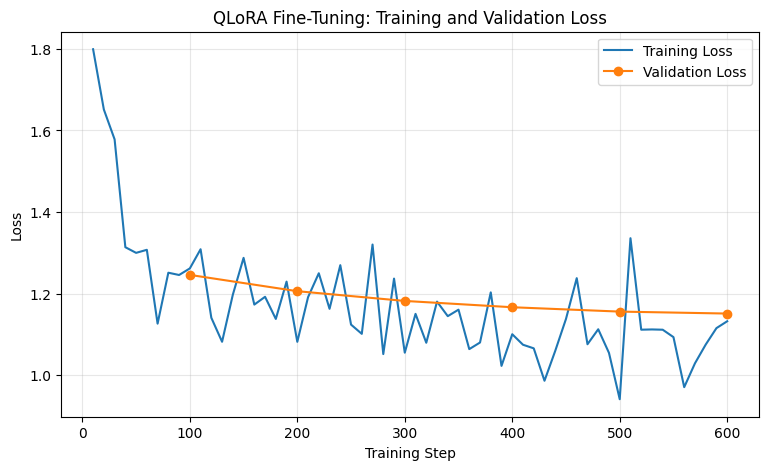

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert trainer logs into a DataFrame
log_df = pd.DataFrame(trainer.state.log_history)

# Training loss records
train_logs = log_df[
    log_df["loss"].notna()
][["step", "loss"]]

# Validation loss records
eval_logs = log_df[
    log_df["eval_loss"].notna()
][["step", "eval_loss"]]

plt.figure(figsize=(9, 5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Training Loss"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("QLoRA Fine-Tuning: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

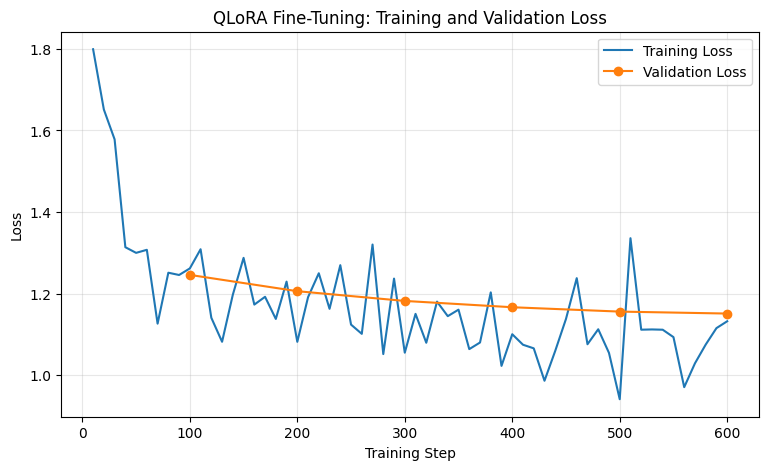

Loss graph saved to Google Drive.


In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Training Loss"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("QLoRA Fine-Tuning: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

loss_plot_path = (
    "/content/drive/MyDrive/"
    "Medical_QLoRA_Unsloth_Month1/"
    "training_validation_loss.png"
)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss graph saved to Google Drive.")

##  Display Readable Qualitative Comparison

The held-out evaluation results are wrapped and formatted for easier comparison of the **base model**, **fine-tuned model**, and **reference MedQuAD answers**.

In [ ]:
import textwrap

for i, row in evaluation_cases.iterrows():
    print("\n" + "=" * 100)
    print("CATEGORY:", row["qtype"])

    print("\nQUESTION:")
    print(textwrap.fill(str(row["Question"]), width=100))

    print("\nBASE MODEL ANSWER:")
    print(textwrap.fill(str(row["Base_Model_Answer"]), width=100))

    print("\nFINE-TUNED MODEL ANSWER:")
    print(textwrap.fill(str(row["Fine_Tuned_Answer"]), width=100))

    print("\nREFERENCE MEDQUAD ANSWER:")
    print(textwrap.fill(str(row["Reference_Answer"]), width=100))


CATEGORY: symptoms

QUESTION:
What are the symptoms of Ichthyosis follicularis atrichia photophobia syndrome ?

BASE MODEL ANSWER:
Ichthyosis follicularis atrichia photophobia syndrome, also known as Harlequin Ichthyosis, is a rare
genetic disorder that affects the skin and hair. The symptoms of this condition can vary in severity
and may include:  1. Severe scaling and dryness of the skin: The skin is often extremely dry, scaly,
and thickened, with a characteristic "fish scale" appearance. 2. Hair loss: The hair on the scalp,
face, and body is often sparse or absent, leading to a condition known as atrichia (hair loss). 3.
Photophobia: As the name suggests, people with Harlequin Ichthyosis often experience sensitivity to
light, which can cause discomfort, pain, and even blisters or rashes. 4. Skin fragility: The skin is
extremely fragile and prone to cracking and tearing, especially in areas with high friction, such as
the elbows and knees. 5. Eye problems: The eyes may be affected, 

##  Held-Out Test Evaluation

The fine-tuned model is evaluated on all **600 unseen test examples**. Test loss and perplexity are calculated to measure performance on data that was not used during training or validation.

In [ ]:
from transformers.utils.notebook import NotebookProgressCallback
import math

# Remove the Colab notebook progress callback
test_trainer.remove_callback(NotebookProgressCallback)

# Evaluate again without the problematic notebook progress display
test_metrics = test_trainer.evaluate()

test_loss = test_metrics["eval_loss"]
test_perplexity = math.exp(test_loss)

print("=== Held-Out Test Evaluation ===")
print("Test examples:", len(test_dataset))
print("Test loss:", round(test_loss, 4))
print("Test perplexity:", round(test_perplexity, 4))

=== Held-Out Test Evaluation ===
Test examples: 600
Test loss: 1.1253
Test perplexity: 3.0813


##  Save Final Project Metrics

The key dataset, training, and evaluation results are summarized in a single table and saved to Google Drive for documentation and reporting.

In [ ]:
import pandas as pd

final_metrics = pd.DataFrame({
    "Metric": [
        "Raw dataset size",
        "Cleaned dataset size",
        "Training examples",
        "Validation examples",
        "Test examples",
        "Trainable parameters",
        "Trainable percentage",
        "Final validation loss",
        "Held-out test loss",
        "Held-out test perplexity"
    ],
    "Value": [
        16407,
        16359,
        4800,
        600,
        600,
        24313856,
        0.7511,
        1.151072,
        round(test_loss, 4),
        round(test_perplexity, 4)
    ]
})

metrics_path = (
    "/content/drive/MyDrive/"
    "Medical_QLoRA_Unsloth_Month1/"
    "final_metrics.csv"
)

final_metrics.to_csv(metrics_path, index=False)

print(final_metrics.to_string(index=False))
print("\nFinal metrics saved to Google Drive.")

                  Metric        Value
        Raw dataset size 1.640700e+04
    Cleaned dataset size 1.635900e+04
       Training examples 4.800000e+03
     Validation examples 6.000000e+02
           Test examples 6.000000e+02
    Trainable parameters 2.431386e+07
    Trainable percentage 7.511000e-01
   Final validation loss 1.151072e+00
      Held-out test loss 1.125300e+00
Held-out test perplexity 3.081300e+00

Final metrics saved to Google Drive.


##  Conclusion

This project successfully fine-tuned **Llama 3.2 3B Instruct** for medical question answering using **4-bit QLoRA and Unsloth**. Only **0.75% of the model parameters** were trained, demonstrating an efficient parameter-efficient fine-tuning approach.

The model was trained on **4,800 medical Q&A examples**, evaluated on separate validation data, and finally tested on **600 unseen examples**, achieving a held-out test loss of **1.1253** and perplexity of **3.0813**. Qualitative comparisons also showed improved alignment with domain-specific medical answers after fine-tuning.

The trained LoRA adapter, evaluation results, loss graph, and final metrics were saved to Google Drive for future reuse and documentation.

> **Disclaimer:** This model was developed for educational and research purposes only and should not be used as a substitute for professional medical advice, diagnosis, or treatment.